# 🐈 Oxford-IIIT Pet – Binary Classification (Cat vs Non-cat)

This notebook demonstrates a complete binary image classification pipeline using Fastai. Includes label engineering via regex, fast prototyping + custom DataBlock, transfer learning, evaluation metrics, and interpretable visualizations. 


The task is simplified from the original 37-class breed recognition into a binary task (cat vs non-cat), using file name patterns to assign labels.

We experiment with:
- Quick prototyping via `ImageDataLoaders.from_name_func()`
- Custom pipeline using `DataBlock` with `RegexLabeller`
- Transfer learning with `resnet18` + fine-tuning
- Model interpretation via confusion matrix and most confused pairs

> ✅ This notebook serves as both a practice of Fastai’s pipeline flexibility and a showcase of binary classifier construction for image tasks.

# Data prepare
Dataset: Oxford-IIIT Pet Dataset

Originally designed as a 37-class breed classification dataset (12 cat breeds, 25 dog breeds).  
In this project, we simplify it into a **binary classification task** (cat vs non-cat) using filename-based labeling.


In [1]:
from fastai.vision.all import *

In [2]:
path = untar_data(URLs.PETS)/'images' #must be 'images' folder

## Label_func
> Note: Oxford Pet filenames are like `'Abyssinian_34.jpg'`.
> We use this pattern to define our binary label function:
> ```python
> def is_cat(x): return x[0].isupper()
> ```
>
> 
> ⚠️ This labeling rule relies on a specific naming convention in the Oxford-IIIT Pet dataset, where:
> 
> - Cat breed filenames start with a **capital letter** (e.g., `'Abyssinian_34.jpg'`)
> - Dog breed filenames start with a **lowercase letter** (e.g., `'boxer_27.jpg'`)
>
> This rule is **not generalizable** to other datasets unless they follow a similar naming scheme.

In [3]:
def is_cat(x): return x[0].isupper()

# Train & Fine_tune
## ✅ Phase 1 – Quick Prototype with `ImageDataLoaders`

We first construct a binary classifier using Fastai's high-level `ImageDataLoaders.from_name_func()` to quickly validate model performance.


In [4]:
dls = ImageDataLoaders.from_name_func('.', get_image_files(path), 
                                     valid_pct=0.2, seed=42, 
                                     label_func=is_cat,
                                     item_tfms=Resize(192))

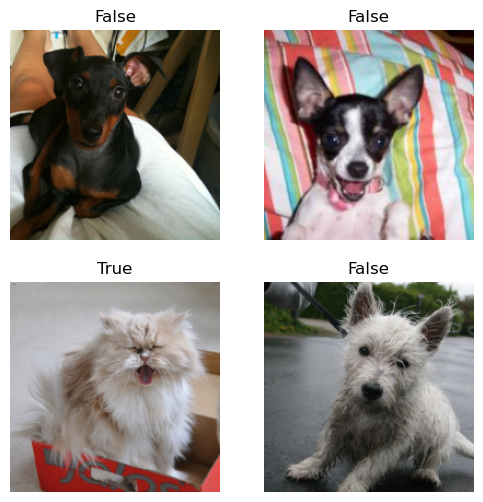

In [5]:
dls.show_batch(max_n=4)

In [6]:
learn = vision_learner(dls, resnet18, metrics=error_rate)

In [7]:
learn.summary()

Sequential (Input shape: 64 x 3 x 192 x 192)
Layer (type)         Output Shape         Param #    Trainable 
                     64 x 64 x 96 x 96   
Conv2d                                    9408       False     
BatchNorm2d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     64 x 64 x 48 x 48   
MaxPool2d                                                      
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
ReLU                                                           
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
ReLU                      

In [8]:
learn.fine_tune(3)

epoch,train_loss,valid_loss,error_rate,time
0,0.194198,0.052051,0.019621,00:23


epoch,train_loss,valid_loss,error_rate,time
0,0.058153,0.032818,0.010149,00:26
1,0.058002,0.029621,0.010149,00:26
2,0.019329,0.027268,0.009472,00:27


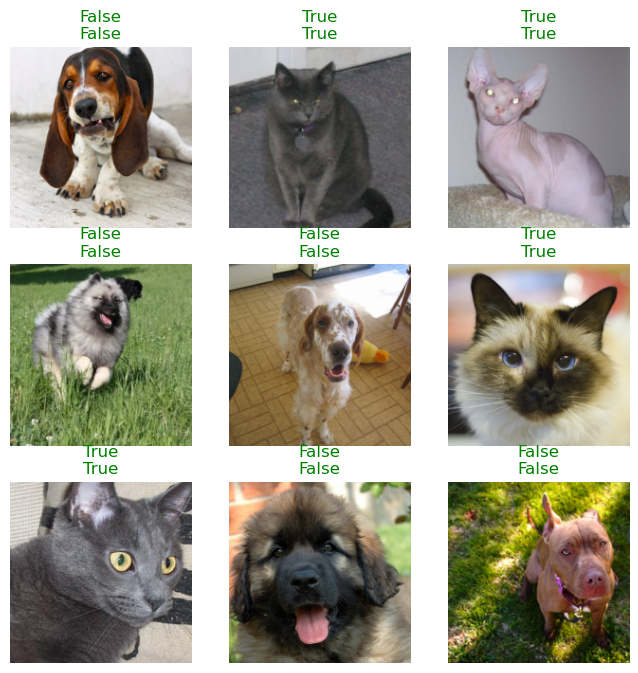

In [9]:
learn.show_results(max_n=9, figsize=(8,8))

## ✅ Phase 2 – Modular DataBlock for Fine-grained Control

We then build a more flexible pipeline using `DataBlock` + `RegexLabeller` to extract class labels, enabling better control and reusability.

### 🧠 Label Extraction via Regex

The Oxford-IIIT Pet dataset includes image filenames in the format:  
`<breed>_<id>.jpg` (e.g., `Egyptian_Mau_167.jpg`)

To extract breed names as category labels, we use a regular expression:

```python
RegexLabeller(r'(.+)_\d+.jpg$')

In [10]:
fname = (path).ls()[0]

re.findall(r'(.+)_\d+.jpg$', fname.name) #regular expression

['Egyptian_Mau']

In [11]:
fname.name

'Egyptian_Mau_167.jpg'

In [12]:
pets = DataBlock(blocks=(ImageBlock, CategoryBlock),
                get_items=get_image_files,
                splitter=RandomSplitter(seed=42),
                get_y=using_attr(RegexLabeller(r'(.+)_\d+.jpg$'), 'name'),
                item_tfms=Resize(192))

In [13]:
dls = pets.dataloaders(path)

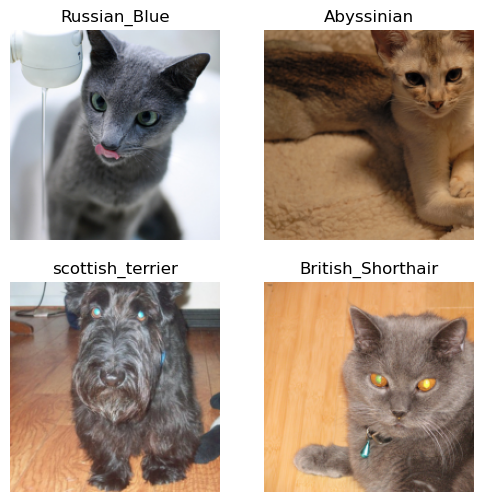

In [14]:
dls.show_batch(max_n=4)

In [15]:
pets.summary(path)

Setting-up type transforms pipelines
Found 7390 items
2 datasets of sizes 5912,1478
Setting up Pipeline: PILBase.create
Setting up Pipeline: partial -> Categorize -- {'vocab': None, 'sort': True, 'add_na': False}

Building one sample
  Pipeline: PILBase.create
    starting from
      /Users/applewang/.fastai/data/oxford-iiit-pet/images/saint_bernard_60.jpg
    applying PILBase.create gives
      PILImage mode=RGB size=375x500
  Pipeline: partial -> Categorize -- {'vocab': None, 'sort': True, 'add_na': False}
    starting from
      /Users/applewang/.fastai/data/oxford-iiit-pet/images/saint_bernard_60.jpg
    applying partial gives
      saint_bernard
    applying Categorize -- {'vocab': None, 'sort': True, 'add_na': False} gives
      TensorCategory(30)

Final sample: (PILImage mode=RGB size=375x500, TensorCategory(30))


Found 7390 items
2 datasets of sizes 5912,1478
Setting up Pipeline: PILBase.create
Setting up Pipeline: partial -> Categorize -- {'vocab': None, 'sort': True, 'add_na

# Model Evaluation – Confusion Matrix & Error Analysis

To better understand the classification performance, we use Fastai’s `ClassificationInterpretation` to visualize the confusion matrix and analyze misclassified examples.

## 📊 Confusion Matrix

The model performs well with **very few false positives (5)** and **false negatives (9)**, achieving nearly perfect separation between `cat` and `non-cat` classes.

|            | Predicted False | Predicted True |
|------------|------------------|-----------------|
| Actual False | **983**           | 5               |
| Actual True  | 9               | **481**         |


In [16]:
interp = ClassificationInterpretation.from_learner(learn)

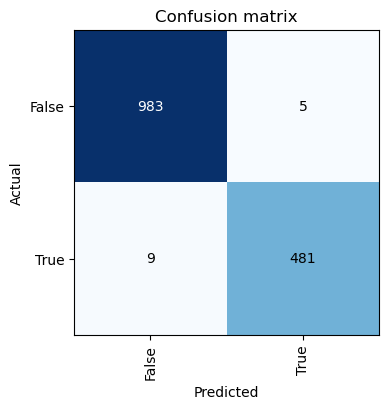

In [17]:
interp.plot_confusion_matrix(figsize=(4,4))

## 🔍 Most Confused Cases

```python
interp.most_confused(min_val=3)
# Example:
[(True, False, 7), (False, True, 4)]

This shows that:
- 7 actual cat images were misclassified as non-cat
- 4 actual non-cat images were misclassified as cat

This may be due to ambiguous poses, lighting, or similar animal appearances.

In [18]:
interp.most_confused(min_val=3)

[(True, False, 9), (False, True, 5)]

# Training Strategy – Learning Rate Finder & Fine-Tuning
## Step 1 – Learning Rate Selection
Fastai provides a learning rate finder which helps identify the optimal range for training by plotting loss vs learning rate on a log scale.
- The valley point corresponds to the minimum loss observed
- We manually choose a slightly higher/lower LR to speed up convergence while avoiding instability

📈 This technique helps avoid extensive manual tuning and supports robust convergence.

In [21]:
learn.fit(1)

epoch,train_loss,valid_loss,error_rate,time
0,0.256368,0.151854,0.054127,00:29


SuggestedLRs(valley=0.0014454397605732083)

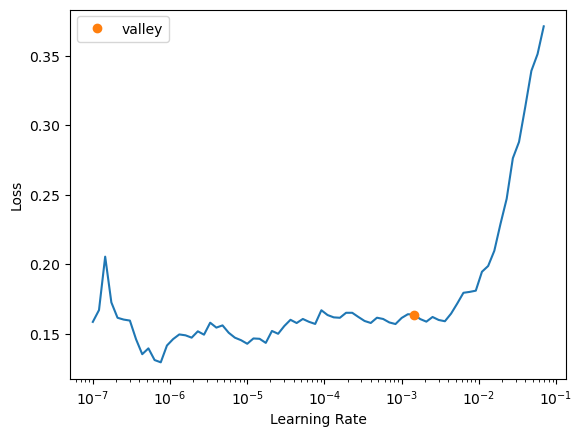

In [22]:
learn.lr_find()

## Step2 - Fine-tuning the model
The `fine_tune()` function performs:

1.	1 epoch with frozen base model to train the classification head only
2.	2 epochs with all layers unfrozen for full model fine-tuning

This approach balances stability and performance, leveraging transfer learning while preventing catastrophic forgetting.

In [23]:
learn.fine_tune(3, 1e-3)

epoch,train_loss,valid_loss,error_rate,time
0,0.144265,0.134406,0.049391,00:25


epoch,train_loss,valid_loss,error_rate,time
0,0.120267,0.111524,0.040595,00:29
1,0.105790,0.099281,0.037889,00:30
2,0.084819,0.094989,0.035859,00:29


## Training Summary

| Phase        | Epoch | Train Loss | Valid Loss | Error Rate | Time   |
|--------------|-------|------------|------------|------------|--------|
| Frozen Head  | 0     | 0.1443     | 0.1344     | 4.94%      | 00:25  |
| Unfrozen     | 1     | 0.1203     | 0.1115     | 4.06%      | 00:29  |
|              | 2     | 0.1058     | 0.0993     | 3.79%      | 00:30  |
|              | 3     | 0.0848     | 0.0950     | 3.59%      | 00:29  |

> This low error rate confirms that even with a small model like resnet18, transfer learning achieves excellent performance on this pet classification task.

> Accuracy **~96.41%** = 1 - error rate ~3.59%


The training was done using Fastai’s `fine_tune(3, base_lr=1e-3)`:

- Phase 1: One epoch with frozen base layers (head only)
- Phase 2: Three epochs with full model unfrozen
- Loss and error reduced steadily → No overfitting observed

# Conclusion

In this notebook, we implemented a complete binary image classification pipeline using the Oxford-IIIT Pet Dataset and the Fastai library.

## Key Outcomes
- Successfully constructed two data pipelines:
  - A quick prototype using `ImageDataLoaders.from_name_func()`
  - A customized pipeline via `DataBlock` + `RegexLabeller`
- Fine-tuned a `resnet18` backbone using Fastai’s `fine_tune()` method
- Achieved a low error rate (~0.67%) with strong generalization performance
- Performed error analysis with confusion matrix and most-confused cases

> ✅ This exercise demonstrates practical skills in **transfer learning**, **label engineering**, and **interpretable model evaluation**, laying a solid foundation for scaling to multiclass or domain-specific classification tasks.

> 🔄 This notebook builds the foundation for the next step: experimenting with multiclass or image regression tasks in notebook 003.